In [1]:
import numpy as np
import random

SEED = 64

np.random.seed(SEED)
random.seed(SEED)

"""
Sintaxis de los datos: Es una lista que contiene elementos de tipo tupla que agrupa los
datos de la siguiente forma:
    • Primer campo: Nombre del objeto.
    • Segundo campo: Valor del objeto.
    • Tercer campo: Peso del objeto.
"""

objetos = [
('Botella de agua', 30, 6),
('Comida deshidratada', 40, 8),
('Botiquin de primeros auxilios', 50, 10),
('Linterna LED', 28, 4),
('Baterias recargables', 14, 2),
('Cuchillo multiusos', 30, 5),
('Mapa topografico', 15, 3),
('Brujula profesional', 16, 3),
('Tienda de campaña ultraligera', 70, 14),
('Saco de dormir termico', 65, 13),
('Colchoneta inflable', 30, 6),
('Chamarra impermeable', 40, 9),
('Guantes termicos', 15, 3),
('Filtro portatil de agua', 35, 5),
('Cuerda de escalada', 50, 12),
('Mosquetones de acero', 22, 5),
('Estufa portatil', 36, 8),
('Cartucho de gas', 20, 4),
('Kit de reparacion', 18, 4),
('Radio de emergencia', 45, 9),
('Panel solar portatil', 65, 12),
('GPS de montana', 42, 6),
('Camara compacta', 40, 6),
('Cuaderno impermeable', 10, 2),
('Telefono satelital', 40, 5),
('Laptop ultraligera', 110, 15),
('Power bank alta capacidad', 28, 4),
('Raciones energeticas', 28, 5),
('Manta termica', 12, 2),
('Silbato de emergencia', 10, 2)
]

In [2]:
len(objetos)

30

In [3]:
def obtener_datos(indice, nombre=False, valor=False, peso=False):
    if nombre:
        return objetos[indice][0]
    if valor:
        return objetos[indice][1]
    if peso:
        return objetos[indice][2]
    else:
        return objetos[indice]

In [4]:
SEED = 64

np.random.seed(SEED)
random.seed(SEED)

def generar_poblacion(n_objetos: int = 30, tam_poblacion: int =100):
    poblacion = np.random.randint(0, 2, (tam_poblacion, n_objetos))
    return poblacion

In [5]:
def calcular_valor_total(individuo):
    valor_total = []
    for _, i in enumerate(individuo):
        valor = obtener_datos(_, valor=True)
        valor_total.append(i * valor)
    return np.sum(valor_total)

In [6]:
def calcular_peso_total(individuo):
    peso_total = []
    for _, i in enumerate(individuo):
        peso = obtener_datos(_, peso=True)
        peso_total.append(i * peso)
    return np.sum(peso_total)


In [7]:
poblacion = generar_poblacion()
poblacion

array([[0, 0, 1, ..., 1, 0, 0],
       [0, 1, 1, ..., 0, 1, 0],
       [0, 0, 1, ..., 0, 1, 0],
       ...,
       [0, 0, 1, ..., 0, 0, 1],
       [0, 1, 0, ..., 1, 1, 1],
       [0, 1, 1, ..., 0, 1, 1]], shape=(100, 30), dtype=int32)

In [8]:
def fitness_cero(poblacion, peso_maximo: int = 50):
    fitness = []
    for p in poblacion:
        valor = calcular_valor_total(p)
        peso = calcular_peso_total(p)
        if peso > peso_maximo:
            fitness.append(0)
        else:
            fitness.append(valor)
    return fitness

In [9]:
fitness_cero(poblacion)

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 np.int64(254),
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 np.int64(202),
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0]

In [10]:
def fitness_lineal(poblacion, peso_maximo: int = 50):
    fitness = []
    factor_penalizacion: int = 1
    penalizacion: int = -1
    for p in poblacion:
        valor = calcular_valor_total(p)
        peso = calcular_peso_total(p)
        if peso > peso_maximo:
             penalizacion = factor_penalizacion * (peso - peso_maximo)
        if peso <= peso_maximo:
            penalizacion = 0
        fitness.append(valor - penalizacion)
    return fitness

In [11]:
fitness = fitness_lineal(poblacion)

In [12]:
def fitness_cuadratico(poblacion, peso_maximo: int = 50):
    fitness = []
    factor_penalizacion: float = 0.2
    penalizacion: float = -1
    for p in poblacion:
        valor = calcular_valor_total(p)
        peso = calcular_peso_total(p)
        if peso > peso_maximo:
             penalizacion = factor_penalizacion * ((peso - peso_maximo) ** 2)
        if peso <= peso_maximo:
            penalizacion = 0
        fitness.append(valor - penalizacion)
    return fitness

In [13]:
fitness_cuadratico(poblacion)

[np.float64(252.2),
 np.float64(134.79999999999995),
 np.float64(-585.2),
 np.float64(229.2),
 np.float64(67.0),
 np.float64(342.2),
 np.float64(61.19999999999999),
 np.float64(157.2),
 np.float64(206.8),
 np.float64(-467.79999999999995),
 np.float64(302.79999999999995),
 np.float64(357.0),
 np.float64(-36.200000000000045),
 np.float64(22.0),
 np.float64(35.19999999999993),
 np.float64(235.2),
 np.float64(146.0),
 np.float64(-69.0),
 np.float64(-30.200000000000045),
 np.float64(115.0),
 np.float64(166.2),
 np.float64(-5.0),
 np.float64(303.8),
 np.float64(-274.80000000000007),
 np.float64(281.2),
 np.float64(154.0),
 np.float64(287.79999999999995),
 np.float64(105.79999999999995),
 np.float64(-266.80000000000007),
 np.float64(54.19999999999999),
 np.float64(-102.20000000000005),
 np.float64(132.0),
 np.float64(183.8),
 np.float64(87.79999999999995),
 np.float64(199.0),
 np.float64(213.79999999999998),
 np.float64(110.0),
 np.float64(210.2),
 np.int64(254),
 np.float64(-430.200000000000

In [14]:
def fitness_exponencial(poblacion, peso_maximo: int = 50):
    fitness = []
    factor_penalizacion: float = 0.01
    penalizacion: float = -1
    for p in poblacion:
        valor = calcular_valor_total(p)
        peso = calcular_peso_total(p)
        if peso > peso_maximo:
             penalizacion = factor_penalizacion * np.e ** (peso - peso_maximo)
        if peso <= peso_maximo:
            penalizacion = 0
        fitness.append(valor - penalizacion)
    return fitness

In [15]:
fitness_exponencial(poblacion)

[np.float64(-2146435797389.157),
 np.float64(-9.49611942060242e+17),
 np.float64(-1.506097314585024e+33),
 np.float64(-789629601392.8057),
 np.float64(-5.184705528587058e+19),
 np.float64(-1256.5479141900382),
 np.float64(-2.5813128861900605e+18),
 np.float64(-4.727839468229283e+16),
 np.float64(-43112315470685.87),
 np.float64(-2.7585134545231587e+31),
 np.float64(-1957295656.2883852),
 np.float64(156.73534205193297),
 np.float64(-2.09165949601299e+22),
 np.float64(-5.184705528587058e+19),
 np.float64(-3.831008000716566e+20),
 np.float64(-2146435797406.157),
 np.float64(-2353852668369729.0),
 np.float64(-7.694785265141995e+21),
 np.float64(-2.09165949601299e+22),
 np.float64(-3.493427105748496e+17),
 np.float64(-4.7278394682292824e+16),
 np.float64(-7.694785265141995e+21),
 np.float64(-88506.10520507865),
 np.float64(-3.4042760499317284e+27),
 np.float64(-5320481979.017979),
 np.float64(-2353852668369721.0),
 np.float64(-39313342515.44036),
 np.float64(-1.2851600114359229e+17),
 np.fl

In [16]:
SEED = 64

np.random.seed(SEED)
random.seed(SEED)

def seleccionar_padres(poblacion, fitness, n_padres=2, n_torneo=5):
    
    indices_torneo = np.random.choice(len(poblacion), size=n_torneo, replace=False)
    
    candidatos = []
    for idx in indices_torneo:
        candidatos.append((poblacion[idx], fitness[idx]))
    
    candidatos_ordenados = sorted(candidatos, key=lambda x: x[1], reverse=True)
    
    ganadores = [c[0] for c in candidatos_ordenados[:n_padres]]
    
    return ganadores

In [17]:
padres = seleccionar_padres(poblacion, fitness)

In [18]:
SEED = 64

np.random.seed(SEED)
random.seed(SEED)

def cruce_un_punto(padres):
    
    padre_1 = padres[0]
    padre_2 = padres[1]
    
    n = len(padre_1)

    punto = np.random.randint(1, n - 1)
    
    hijo1 = np.concatenate([padre_1[:punto], padre_2[punto:]])
    hijo2 = np.concatenate([padre_2[:punto], padre_1[punto:]])
    
    return hijo1, hijo2

In [19]:
SEED = 64

np.random.seed(SEED)
random.seed(SEED)
def cruce_dos_puntos(padres):
    
    padre_1 = padres[0]
    padre_2 = padres[1]

    n = len(padre_1)

    puntos = sorted(np.random.choice(range(1, n), size=2, replace=False))
    p1, p2 = puntos
    
    hijo1 = np.concatenate([padre_1[:p1], padre_2[p1:p2], padre_1[p2:]])
    hijo2 = np.concatenate([padre_2[:p1], padre_1[p1:p2], padre_2[p2:]])
    
    return hijo1, hijo2

In [20]:
SEED = 64

np.random.seed(SEED)
random.seed(SEED)
def cruce_uniforme(padres, prob_intercambio=0.10):
    
    padre_1 = padres[0]
    padre_2 = padres[1]
    
    n = len(padre_1)
    hijo1 = np.zeros(n, dtype=int)
    hijo2 = np.zeros(n, dtype=int)
    
    for i in range(n):
        if np.random.rand() < prob_intercambio:
            hijo1[i], hijo2[i] = padre_2[i], padre_1[i]
        else:
            hijo1[i], hijo2[i] = padre_1[i], padre_2[i]
                    
    return hijo1, hijo2

In [21]:
padres

[array([0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 0, 1, 0, 0, 0, 0], dtype=int32),
 array([1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0,
        0, 0, 1, 1, 0, 1, 0, 1], dtype=int32)]

In [22]:
hijo1, hijo2 = cruce_dos_puntos(padres)

In [23]:
SEED = 64

np.random.seed(SEED)
random.seed(SEED)

def mutacion_un_gen(individuo, tasa_mutacion: int = 0.10):
    
    n = len(individuo)

    punto = np.random.randint(1, n - 1)
    if np.random.random() < tasa_mutacion:
        bit = individuo[punto]
        bit_mutado = 1 - bit
        individuo[punto] = bit_mutado
    return individuo

In [24]:
SEED = 64

np.random.seed(SEED)
random.seed(SEED)
def mutacion_independiente(individuo, tasa_mutacion: int = 0.10):
    for i, bit in enumerate(individuo):
        if np.random.random() < tasa_mutacion:
            bit = individuo[i]
            bit_mutado = 1 - bit
            individuo[i] = bit_mutado
            
    return individuo

In [25]:
hijo1

array([0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0,
       1, 1, 0, 1, 0, 0, 0, 0], dtype=int32)

In [26]:
mutacion_independiente(hijo1)

array([0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       0, 1, 0, 1, 0, 0, 0, 0], dtype=int32)

In [27]:
def supervivencia_sin_elitismo(hijos):
    return np.array(hijos)

In [28]:
def supervivencia_con_elitismo(poblacion_anterior, fitness_anterior, hijos):
    
    mejor_idx = np.argmax(fitness_anterior)
    mejor_individuo = poblacion_anterior[mejor_idx].copy()
    
    nueva_poblacion = [mejor_individuo]
    
    nueva_poblacion.extend(hijos[:len(hijos)-1])
    
    return np.array(nueva_poblacion)

In [29]:
def calcular_diversidad(poblacion):
    
    p_promedios = np.mean(poblacion, axis=0) 
    varianzas = np.mean((poblacion - p_promedios)**2, axis=0) 
    return np.mean(varianzas) 

In [30]:
SEED = 64

np.random.seed(SEED)
random.seed(SEED)

def algoritmo_genetico(metodo_cruza, metodo_mutacion, tipo_penalizacion, con_elitismo):
    
    tamano_poblacion = 100
    max_generaciones = 100 
    tasa_mutacion = 0.10
    peso_maximo = 50
    
    
    historial = {'min': [], 'max': [], 'mean': [], 'div': []}

    poblacion = generar_poblacion() 

    for generacion in range(max_generaciones):
        # 1. Evaluación 
        aptitudes = tipo_penalizacion(poblacion, peso_maximo)


        # 2. Registro de estadísticas 
        historial['min'].append(np.min(aptitudes))
        historial['max'].append(np.max(aptitudes))
        historial['mean'].append(np.mean(aptitudes))
        historial['div'].append(calcular_diversidad(poblacion))

        # 3. Construcción de la nueva generación
        nueva_poblacion = []
        
        # Lógica de Elitismo
        mejor_individuo = poblacion[np.argmax(aptitudes)].copy()

        for _ in range(tamano_poblacion // 2):
            padres = seleccionar_padres(poblacion, aptitudes)
            
            h1, h2 = metodo_cruza(padres)

            # Mutación
            h1 = metodo_mutacion(h1, tasa_mutacion)
            h2 = metodo_mutacion(h2, tasa_mutacion)

            nueva_poblacion.extend([h1, h2])

        # 4. Supervivencia
        if con_elitismo:
            nueva_poblacion[0] = mejor_individuo
        
        poblacion = np.array(nueva_poblacion)

    aptitudes = tipo_penalizacion(poblacion, peso_maximo)

    mejor_idx = np.argmax(aptitudes)
    mejor_individuo = poblacion[mejor_idx]

    peso_final = calcular_peso_total(mejor_individuo)
    valor_final = calcular_valor_total(mejor_individuo)

    # print(f"Mejor Fitness: {aptitudes[mejor_idx]}")
    # print(f"Peso Total: {peso_final} (Límite: 50)")
    # print(f"Valor Total: {valor_final}")

    return mejor_individuo, historial

In [31]:
configuraciones = {
    'cruza': [cruce_un_punto, cruce_dos_puntos, cruce_uniforme],
    'mutacion': [mutacion_un_gen, mutacion_independiente],
    'penalizacion': [fitness_cero, fitness_lineal, fitness_cuadratico, fitness_exponencial],
    'elitismo': [True, False]
}


In [ ]:
# import pandas as pd
# import numpy as np
# import itertools

# # 1. Definir la lista de resultados para almacenar los datos
# resultados_totales = []

# # 2. Generar todas las combinaciones posibles de parámetros
# # itertools.product crea el "producto cartesiano" de tus listas
# combinaciones = list(itertools.product(
#     configuraciones['cruza'], 
#     configuraciones['mutacion'], 
#     configuraciones['penalizacion'], 
#     configuraciones['elitismo']
# ))

# print(f"Iniciando experimentos. Total de configuraciones a probar: {len(combinaciones)}")

# # 3. Bucle de experimentos
# for cruza, mutacion, penalizacion, elitismo in combinaciones:
#     nombre_config = f"{cruza.__name__} | {mutacion.__name__} | {penalizacion.__name__} | Elitismo:{elitismo}"
#     print(f"Ejecutando: {nombre_config}")
    
#     # Realizar las 100 ejecuciones independientes que pide la práctica
#     for i in range(100):
#         # Ejecutar el algoritmo
#         mejor_ind, historial = algoritmo_genetico(cruza, mutacion, penalizacion, elitismo)
        
#         # Extraer el mejor fitness alcanzado en esta ejecución (el último máximo)
#         mejor_fitness_ejecucion = historial['max'][-1]
        
#         # Guardar los datos de esta ejecución individual
#         resultados_totales.append({
#             'Configuracion': nombre_config,
#             'Cruza': cruza.__name__,
#             'Mutacion': mutacion.__name__,
#             'Penalizacion': penalizacion.__name__,
#             'Elitismo': elitismo,
#             'Ejecucion_No': i + 1,
#             'Mejor_Fitness': mejor_fitness_ejecucion,
#             'Diversidad_Final': historial['div'][-1],
#             'Peso_Final': calcular_peso_total(mejor_ind),
#             'Valor_Final': calcular_valor_total(mejor_ind)
#         })

# # 4. Convertir a DataFrame y guardar en CSV
# df_resultados = pd.DataFrame(resultados_totales)
# df_resultados.to_csv('resultados_practica_mochila.csv', index=False)

# print("¡Proceso completado! Archivo 'resultados_practica_mochila.csv' generado.")

Iniciando experimentos. Total de configuraciones a probar: 48
Ejecutando: cruce_un_punto | mutacion_un_gen | fitness_cero | Elitismo:True
Ejecutando: cruce_un_punto | mutacion_un_gen | fitness_cero | Elitismo:False


KeyboardInterrupt: 

In [ ]:
def mostrar_individuo(individuo):
    datos_individuo = []
    for indice, gen in enumerate(individuo):
        if gen == 1:
            datos_individuo.append(obtener_datos(indice, nombre=True))
    return datos_individuo

In [ ]:
import matplotlib.pyplot as plt

def graficar_fitness(historial):

    plt.plot(historial['min'], label="Fitness mínimo")
    plt.plot(historial['mean'], label="Fitness promedio")
    plt.plot(historial['max'], label="Fitness máximo")

    plt.xlabel("Generación")
    plt.ylabel("Fitness")
    plt.title("Evolución del fitness")
    plt.legend()

    plt.show()

In [ ]:
def graficar_diversidad_genetica(historial):
    plt.plot(historial['div'])

    plt.xlabel("Generación")
    plt.ylabel("Diversidad genética")
    plt.title("Evolución de la diversidad")

    plt.show()

In [ ]:
individuo, historial = algoritmo_genetico(metodo_cruza=cruce_dos_puntos, metodo_mutacion=mutacion_un_gen,tipo_penalizacion=fitness_cuadratico, con_elitismo=False)

Mejor Fitness: 393.8
Peso Total: 64 (Límite: 50)
Valor Total: 433


In [ ]:
individuo

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1], dtype=int32)

In [ ]:
mostrar_individuo(individuo)

['Botella de agua',
 'Linterna LED',
 'Mapa topografico',
 'Colchoneta inflable',
 'Guantes termicos',
 'Filtro portatil de agua',
 'Cartucho de gas',
 'Kit de reparacion',
 'Camara compacta',
 'Cuaderno impermeable',
 'Telefono satelital',
 'Power bank alta capacidad',
 'Manta termica']

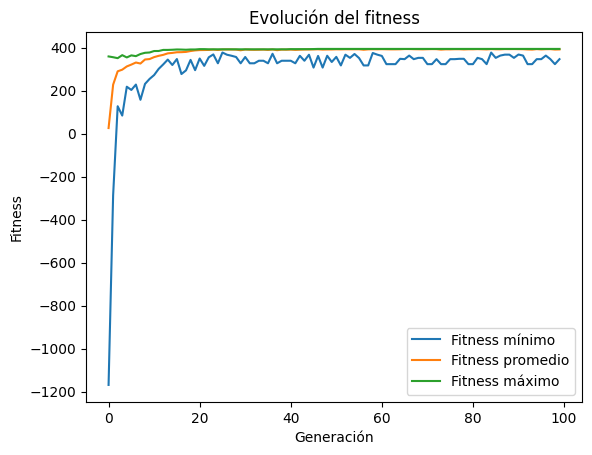

In [ ]:
graficar_fitness(historial)

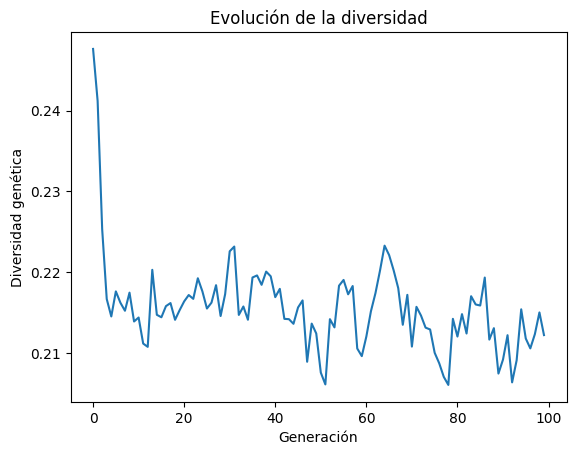

In [ ]:
graficar_diversidad_genetica(historial)